<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


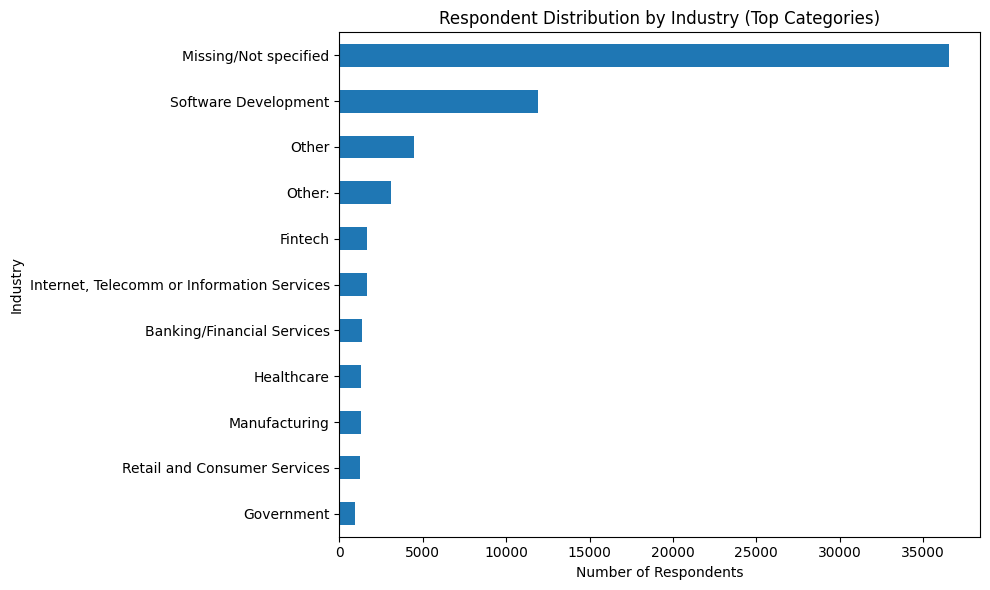

In [3]:
import matplotlib.pyplot as plt

# Include missing as a category (optional but recommended)
industry_counts = df["Industry"].fillna("Missing/Not specified").value_counts()

# Plot top N to avoid a crowded chart
top_n = 10
top_industry = industry_counts.head(top_n)
other_count = industry_counts.iloc[top_n:].sum()

plot_counts = top_industry.copy()
if other_count > 0:
    plot_counts["Other"] = other_count

plt.figure(figsize=(10, 6))
plot_counts.sort_values().plot(kind="barh")
plt.title("Respondent Distribution by Industry (Top Categories)")
plt.xlabel("Number of Respondents")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
import pandas as pd

# Ensure ConvertedCompYearly is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Basic statistics
mean_comp = df["ConvertedCompYearly"].mean()
median_comp = df["ConvertedCompYearly"].median()
std_comp = df["ConvertedCompYearly"].std()

print("Mean:", mean_comp)
print("Median:", median_comp)
print("Std Dev:", std_comp)

# Threshold: 3 standard deviations above the mean
threshold = mean_comp + 3 * std_comp
print("Outlier threshold (mean + 3*std):", threshold)

# Identify high compensation outliers
high_outliers = df[df["ConvertedCompYearly"] > threshold][["ResponseId", "Country", "Employment", "ConvertedCompYearly"]]

high_outliers


Mean: 86155.28726264134
Median: 65000.0
Std Dev: 186756.97308629757
Outlier threshold (mean + 3*std): 646426.2065215341


,ResponseId,Country,Employment,ConvertedCompYearly
529,530,United States of America,"Employed, full-time",650000.0
828,829,United States of America,"Employed, full-time",1000000.0
1932,1933,United States of America,"Employed, full-time",945000.0
2171,2172,United States of America,"Employed, full-time",750000.0
2187,2188,Gabon,"Employed, full-time",2000000.0
...,...,...,...,...
38219,38220,Poland,"Employed, full-time",1000000.0
39643,39644,United States of America,"Employed, full-time",1300000.0
40066,40067,United States of America,"Employed, full-time",800000.0
40952,40953,United States of America,"Employed, full-time",750000.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.0 Q3: 107971.5 IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Number of outliers: 978


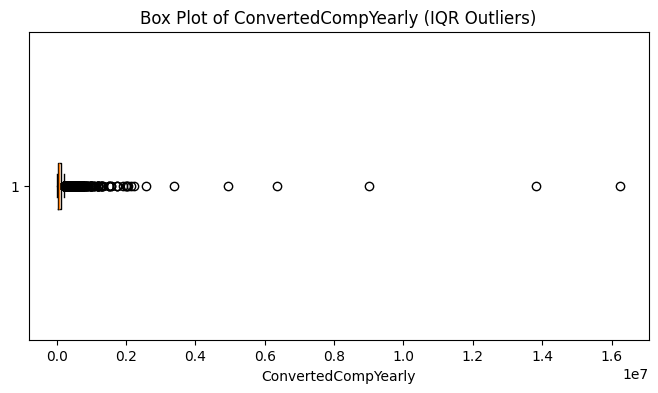

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# 1) Calculate Q1, Q3 and IQR
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)

# 2) Determine outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# 3) Identify and count outliers
outliers = df[(df["ConvertedCompYearly"] < lower_bound) | (df["ConvertedCompYearly"] > upper_bound)]
print("Number of outliers:", outliers.shape[0])

# 4) Visualize using a box plot
plt.figure(figsize=(8, 4))
plt.boxplot(df["ConvertedCompYearly"].dropna(), vert=False)
plt.title("Box Plot of ConvertedCompYearly (IQR Outliers)")
plt.xlabel("ConvertedCompYearly")
plt.show()


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [6]:
# Create a new DataFrame excluding outliers in ConvertedCompYearly (IQR method)

# Ensure numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Compute IQR bounds
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers (keep rows within bounds)
df_no_outliers = df[(df["ConvertedCompYearly"] >= lower_bound) & (df["ConvertedCompYearly"] <= upper_bound)].copy()

# Validate size
print("Original DataFrame size:", df.shape)
print("New DataFrame size (no outliers):", df_no_outliers.shape)
print("Rows removed:", df.shape[0] - df_no_outliers.shape[0])


Original DataFrame size: (65437, 114)
New DataFrame size (no outliers): (22457, 114)
Rows removed: 42980


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Map Age ranges to approximate numeric values
age_map = {
    "Under 18 years old": 16,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 70,
    "Prefer not to say": pd.NA
}

df["Age_numeric"] = df["Age"].map(age_map)

# 2) Compute correlations between Age and other numeric variables
numeric_df = df.select_dtypes(include="number").copy()

corr_matrix = numeric_df.corr()  # Pearson correlation by default
corr_matrix["Age_numeric"].sort_values(ascending=False)

# 3) Visualize correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Variables, including Age_numeric)")
plt.tight_layout()
plt.show()


KeyError: 'Age_numeric'

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
